# Paso 3 — Construcción y comparación de modelos

En este notebook se construye la etapa de **Model Building** del proyecto de Mantenimiento Predictivo.

Partimos del dataset generado en `2_feature_engineering.ipynb` y desarrollamos un flujo reproducible para:

- separar variables predictoras y objetivo;
- analizar la distribución de la variable `y`;
- diagnosticar desbalance de clases;
- aplicar **SMOTE únicamente sobre entrenamiento y dentro del Pipeline** cuando sea necesario;
- establecer **Logistic Regression como baseline**;
- comparar Decision Tree, Random Forest y Gradient Boosting;
- utilizar **Stratified K-Fold Cross Validation**;
- evaluar desempeño sobre un conjunto de prueba aislado;
- analizar señales de sobreajuste;
- seleccionar el mejor modelo mediante **F1 Macro**;
- guardar el modelo y sus métricas para las siguientes etapas.

> El objetivo es completar un flujo de Machine Learning reproducible: datos → entrenamiento → validación → selección → modelo persistido.


## Objetivo

Construir y comparar cuatro modelos de clasificación para predecir fallas:

1. **Logistic Regression** — baseline
2. **Decision Tree**
3. **Random Forest**
4. **Gradient Boosting**

### Métricas

- Accuracy
- Precision
- Recall
- F1
- F1 Macro
- ROC-AUC

### Criterio principal

Usaremos **F1 Macro** como métrica principal porque asigna el mismo peso a cada clase, algo especialmente importante cuando existe desbalance.

El conjunto de prueba se mantiene aislado y solo se utiliza para la evaluación final.


## Flujo del notebook

```text
Dataset
   ↓
X / y
   ↓
Distribución de clases
   ↓
Train / Test
   ↓
Diagnóstico de imbalance
   ↓
Baseline Logistic Regression
   ↓
Cross Validation
   ↓
4 modelos
   ↓
Cross Validation de modelos
   ↓
Entrenamiento final
   ↓
Comparación
   ↓
Análisis de overfitting
   ↓
Mejor modelo
   ↓
Matriz de confusión
   ↓
Classification Report
   ↓
Feature Importance
   ↓
Guardar modelo
```


## 01. Librerías

Importamos las librerías necesarias para manipulación de datos, entrenamiento, validación, métricas, visualización y persistencia.

Utilizamos `imbalanced-learn` para aplicar **SMOTE** de forma segura dentro de los pipelines. Esto evita que los datos sintéticos generados por SMOTE contaminen los folds de validación.

### Compatibilidad del entorno Azure ML

Este notebook está preparado para el runtime **Python 3.10 - AzureML** y utiliza una combinación compatible con el entorno base:

- `numpy==1.26.4`
- `scipy==1.10.1`
- `scikit-learn==1.5.2`
- `imbalanced-learn==0.12.4`

> No se recomienda actualizar `scikit-learn` o `scipy` a versiones superiores en el Compute base de Azure ML, porque pueden entrar en conflicto con paquetes preinstalados de Azure ML.


In [1]:
#%pip install imbalanced-learn==0.12.4

In [2]:
# ==========================================
# 01. Librerías
# ==========================================

import os
import time
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

print("Librerías cargadas correctamente.")
print("numpy:", np.__version__)
print("scikit-learn:", __import__("sklearn").__version__)
print("imbalanced-learn:", __import__("imblearn").__version__)


Librerías cargadas correctamente.
numpy: 1.23.5
scikit-learn: 1.5.1
imbalanced-learn: 0.12.4


## 02. Configuración

Definimos las rutas del dataset y de los artefactos generados.

También establecemos:

- semilla reproducible;
- proporción Train/Test;
- número de folds para Cross Validation;
- umbrales prácticos para diagnosticar desbalance.

Los modelos se almacenarán en `models/` para ser utilizados posteriormente en inferencia y despliegue.


In [3]:
# ==========================================
# 02. Configuración
# ==========================================

INPUT_PATH = "../data/output_data/featureengineering_files.parquet"
MODEL_DIR = "../models"

os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.30
N_SPLITS = 5

# Criterios prácticos de imbalance para este laboratorio
IMBALANCE_RATIO_THRESHOLD = 3.0
MINORITY_SHARE_THRESHOLD = 0.20

print("Dataset:", INPUT_PATH)
print("Modelos:", MODEL_DIR)


Dataset: ../data/output_data/featureengineering_files.parquet
Modelos: ../models


## 03. Carga del dataset

Cargamos el dataset generado en el notebook de Feature Engineering.

No repetimos aquí las transformaciones realizadas anteriormente. Esta etapa se concentra exclusivamente en la construcción y evaluación de modelos.


In [4]:
# ==========================================
# 03. Carga del dataset
# ==========================================

labeled_features = pd.read_parquet(INPUT_PATH)

print("Dimensiones:", labeled_features.shape)

display(labeled_features.head())


Dimensiones: (73143, 42)


,machineID,dt_truncated,volt_rollingmean_12,volt_rollingstd_12,rotate_rollingmean_12,rotate_rollingstd_12,pressure_rollingmean_12,pressure_rollingstd_12,vibration_rollingmean_12,vibration_rollingstd_12,...,comp2sum,comp3sum,comp4sum,age,model_model1,model_model2,model_model3,model_model4,failure,label_e
0,1,2015-01-01 00:00:00,169.512597,6.239068,425.853115,46.581966,101.886267,13.166950,41.119335,4.473233,...,213.0,153.0,168.0,18,0,0,1,0,0.0,0.0
1,1,2015-01-01 12:00:00,167.007032,8.260186,434.948972,50.000568,100.970047,10.863588,39.412711,5.716674,...,214.0,154.0,169.0,18,0,0,1,0,0.0,4.0
2,1,2015-01-02 00:00:00,171.754734,13.479925,454.534311,44.925868,93.989345,7.963589,40.265190,5.761581,...,214.0,154.0,169.0,18,0,0,1,0,0.0,4.0
3,1,2015-01-02 12:00:00,168.184995,15.356860,444.596343,39.260749,100.778017,10.107193,39.209928,5.957205,...,215.0,155.0,170.0,18,0,0,1,0,0.0,4.0
4,1,2015-01-03 00:00:00,172.717240,12.879603,468.079805,40.727721,99.586915,12.005493,40.406556,5.574350,...,215.0,155.0,170.0,18,0,0,1,0,0.0,4.0


## 04. X / y

Separamos:

- `X`: variables predictoras.
- `y`: variable objetivo.

La variable objetivo es `label_e`.

Las columnas identificadoras, temporales o utilizadas para construir la etiqueta se excluyen de `X`.


In [5]:
# ==========================================
# 04. X / y
# ==========================================

TARGET = "label_e"

REMOVE_COLUMNS = [
    "machineID",
    "dt_truncated",
    "datetime",
    "failure",
    "model",
    TARGET
]

input_features = [
    col
    for col in labeled_features.columns
    if col not in REMOVE_COLUMNS
]

X = labeled_features[input_features].copy()
y = labeled_features[TARGET].copy()

print("Variable objetivo:", TARGET)
print("Número de variables:", len(input_features))

print("\nVariables predictoras:")
print(input_features)

print("\nDistribución de y:")
display(y.value_counts().sort_index())


Variable objetivo: label_e
Número de variables: 38

Variables predictoras:
['volt_rollingmean_12', 'volt_rollingstd_12', 'rotate_rollingmean_12', 'rotate_rollingstd_12', 'pressure_rollingmean_12', 'pressure_rollingstd_12', 'vibration_rollingmean_12', 'vibration_rollingstd_12', 'volt_rollingmean_24', 'volt_rollingstd_24', 'rotate_rollingmean_24', 'rotate_rollingstd_24', 'pressure_rollingmean_24', 'pressure_rollingstd_24', 'vibration_rollingmean_24', 'vibration_rollingstd_24', 'volt_rollingmean_36', 'volt_rollingstd_36', 'rotate_rollingmean_36', 'rotate_rollingstd_36', 'pressure_rollingmean_36', 'pressure_rollingstd_36', 'vibration_rollingmean_36', 'vibration_rollingstd_36', 'error1sum_rollingmean_24', 'error2sum_rollingmean_24', 'error3sum_rollingmean_24', 'error4sum_rollingmean_24', 'error5sum_rollingmean_24', 'comp1sum', 'comp2sum', 'comp3sum', 'comp4sum', 'age', 'model_model1', 'model_model2', 'model_model3', 'model_model4']

Distribución de y:


0.0    67454
1.0     1346
2.0     1865
3.0     1000
4.0     1478
Name: label_e, dtype: int64

## 05. Distribución de clases

Antes de entrenar modelos debemos conocer la distribución de la variable objetivo.

Un problema de clasificación está desbalanceado cuando algunas clases tienen muchas más observaciones que otras.

Esto es especialmente relevante en mantenimiento predictivo: una clase mayoritaria puede dominar Accuracy aunque el modelo tenga un desempeño pobre detectando clases de falla.


,Count,Percentage
0.0,67454,92.22
1.0,1346,1.84
2.0,1865,2.55
3.0,1000,1.37
4.0,1478,2.02


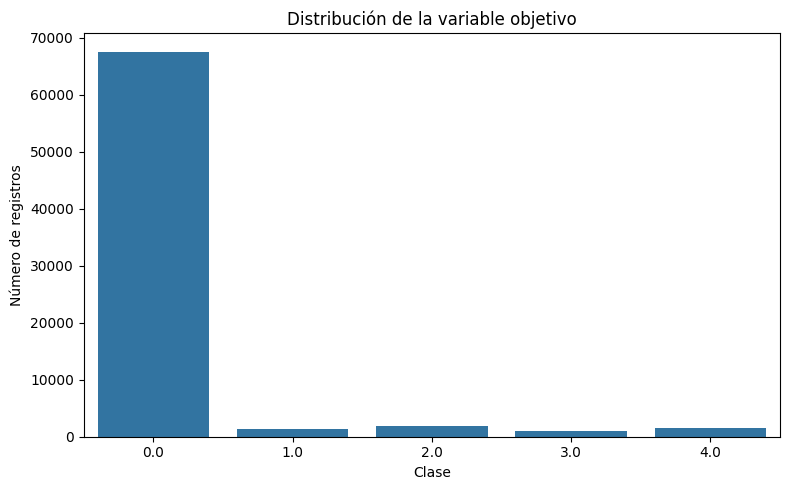

In [6]:
# ==========================================
# 05. Distribución de clases
# ==========================================

class_counts = y.value_counts().sort_index()

class_percentages = (
    y.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

display(class_distribution)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=class_distribution.index.astype(str),
    y=class_distribution["Count"]
)

plt.xlabel("Clase")
plt.ylabel("Número de registros")
plt.title("Distribución de la variable objetivo")

plt.tight_layout()
plt.show()


## 06. Train / Test

Dividimos los datos en:

- **70 % Train**
- **30 % Test**

El conjunto de entrenamiento se utilizará para:

- Cross Validation;
- diagnóstico de imbalance;
- SMOTE cuando sea necesario;
- entrenamiento;
- selección de hiperparámetros en la siguiente etapa.

El conjunto de prueba permanece aislado hasta la evaluación final.

> **Nunca aplicamos SMOTE sobre el Test Set.**


In [7]:
# ==========================================
# 06. Train / Test
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train: {X_train.shape}")
print(f"Test : {X_test.shape}")


Train: (51200, 38)
Test : (21943, 38)


## 07. Diagnóstico de imbalance

Calculamos:

- **Imbalance Ratio** = clase mayoritaria / clase minoritaria.
- **Minority Share** = proporción de la clase minoritaria.

Para este laboratorio consideraremos que existe un desbalance relevante cuando:

- el ratio mayoritaria/minoritaria es `>= 3`; o
- la clase minoritaria representa `< 20 %`.

Estos valores son **reglas prácticas para el laboratorio**, no leyes universales.

### Estrategia

Si existe desbalance:

```text
TRAIN
  ↓
Cross Validation
  ↓
SMOTE dentro de cada fold
  ↓
Entrenamiento
```

Si no existe:

```text
TRAIN
  ↓
Cross Validation
  ↓
Entrenamiento sin resampling
```

> SMOTE se ejecuta únicamente dentro del Pipeline. Así evitamos data leakage.


In [8]:
# ==========================================
# 07. Diagnóstico de imbalance
# ==========================================

train_class_counts = y_train.value_counts().sort_index()

majority_count = train_class_counts.max()
minority_count = train_class_counts.min()

imbalance_ratio = majority_count / minority_count
minority_share = minority_count / train_class_counts.sum()

imbalance_detected = (
    imbalance_ratio >= IMBALANCE_RATIO_THRESHOLD
    or minority_share < MINORITY_SHARE_THRESHOLD
)

print("Distribución de clases en TRAIN:")
display(train_class_counts.to_frame("Count"))

print(f"Imbalance Ratio : {imbalance_ratio:.2f}")
print(f"Minority Share  : {minority_share:.2%}")

if imbalance_detected:
    print("\nSe detecta desbalance relevante.")
    print("SMOTE será utilizado dentro de los pipelines.")
else:
    print("\nNo se detecta un desbalance relevante.")
    print("No se aplicará resampling.")


Distribución de clases en TRAIN:


,Count
0.0,47218
1.0,942
2.0,1305
3.0,700
4.0,1035


Imbalance Ratio : 67.45
Minority Share  : 1.37%

Se detecta desbalance relevante.
SMOTE será utilizado dentro de los pipelines.


### ¿Por qué SMOTE debe estar dentro del Pipeline?

SMOTE genera ejemplos sintéticos de las clases minoritarias.

### Incorrecto

```text
Dataset
   ↓
SMOTE
   ↓
Train / Test
   ↓
Cross Validation
```

Esto puede provocar **data leakage**, porque el proceso de generación de datos sintéticos puede utilizar información que posteriormente termina en validación o Test.

### Correcto

```text
Train
  ↓
Cross Validation
  ↓
Fold
  ↓
SMOTE
  ↓
Entrenamiento
  ↓
Validación
```

De esta forma cada fold genera sus ejemplos sintéticos utilizando exclusivamente los datos disponibles para ese entrenamiento.


## 08. Baseline — Logistic Regression

Logistic Regression será nuestro **baseline**.

El baseline establece un punto de referencia sencillo contra el cual compararemos los modelos más complejos.

Como el modelo es sensible a la escala de las variables utilizamos `StandardScaler`.

Si se detecta desbalance, SMOTE se incorpora al Pipeline:

```text
StandardScaler
      ↓
SMOTE (si es necesario)
      ↓
Logistic Regression
```


In [9]:
# ==========================================
# 08. Baseline - Logistic Regression
# ==========================================

def create_pipeline(model, scale=False):
    steps = []

    if scale:
        steps.append(
            ("scaler", StandardScaler())
        )

    if imbalance_detected:
        steps.append(
            ("smote", SMOTE(
                random_state=RANDOM_STATE
            ))
        )

    steps.append(
        ("classifier", model)
    )

    return Pipeline(steps)


baseline_model = create_pipeline(
    LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    scale=True
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
baseline_proba = baseline_model.predict_proba(X_test)

print("Baseline entrenado correctamente.")


Baseline entrenado correctamente.


## Evaluación del baseline

Calculamos:

- Accuracy
- Precision
- Recall
- F1
- F1 Macro
- ROC-AUC

Para Precision, Recall y F1 utilizamos el promedio `weighted`.

**F1 Macro** calcula el F1 de cada clase y luego obtiene un promedio simple, dando el mismo peso a todas las clases.

Para el problema multiclase utilizamos ROC-AUC **One-vs-Rest**.


In [10]:
# ==========================================
# Evaluación del baseline
# ==========================================

baseline_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(
        y_test, baseline_pred
    ),
    "Precision": precision_score(
        y_test, baseline_pred,
        average="weighted",
        zero_division=0
    ),
    "Recall": recall_score(
        y_test, baseline_pred,
        average="weighted",
        zero_division=0
    ),
    "F1": f1_score(
        y_test, baseline_pred,
        average="weighted",
        zero_division=0
    ),
    "F1 Macro": f1_score(
        y_test, baseline_pred,
        average="macro",
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        baseline_proba,
        multi_class="ovr",
        average="weighted"
    )
}

baseline_metrics_df = pd.DataFrame(
    [baseline_metrics]
)

display(
    baseline_metrics_df.round(4)
)


,Model,Accuracy,Precision,Recall,F1,F1 Macro,ROC-AUC
0,Logistic Regression,0.5175,0.9024,0.5175,0.6301,0.264,0.7945


## 09. Cross Validation

Una única división Train/Test puede depender de cómo quedaron distribuidos los datos.

Utilizamos **Stratified K-Fold Cross Validation** con 5 folds.

La estratificación mantiene aproximadamente la misma proporción de clases en cada fold.

El Test Set permanece aislado.

Cuando existe desbalance, SMOTE se ejecuta dentro del Pipeline en cada fold, evitando data leakage.


In [11]:
# ==========================================
# 09. Cross Validation
# ==========================================

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_weighted",
    "recall": "recall_weighted",
    "f1": "f1_weighted",
    "f1_macro": "f1_macro",
    "roc_auc": "roc_auc_ovr_weighted"
}

cv_results = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "F1 Macro",
        "ROC-AUC"
    ],
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_f1_macro"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_f1_macro"].std(),
        cv_results["test_roc_auc"].std()
    ]
})

display(cv_summary.round(4))


,Metric,Mean,Std
0,Accuracy,0.5166,0.0023
1,Precision,0.9035,0.0014
2,Recall,0.5166,0.0023
3,F1,0.6291,0.0026
4,F1 Macro,0.2654,0.0016
5,ROC-AUC,0.7962,0.0063


## 10. Modelos

Ahora construimos los cuatro algoritmos que participarán en la comparación.

### Logistic Regression
Modelo lineal y baseline.

### Decision Tree
Aprende reglas de decisión y relaciones no lineales. Puede sobreajustarse si crece demasiado.

### Random Forest
Combina múltiples árboles y reduce la varianza respecto a un árbol individual.

### Gradient Boosting
Construye árboles secuencialmente para corregir errores de los modelos anteriores y puede capturar relaciones complejas.

Cuando existe desbalance, SMOTE se incorpora automáticamente dentro de cada Pipeline.


In [12]:
# ==========================================
# 10. Modelos
# ==========================================

models = {

    "Logistic Regression": create_pipeline(
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ),
        scale=True
    ),

    "Decision Tree": create_pipeline(
        DecisionTreeClassifier(
            max_depth=15,
            random_state=RANDOM_STATE
        )
    ),

    "Random Forest": create_pipeline(
        RandomForestClassifier(
            n_estimators=100,
            max_depth=15,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    
    )
    # ),
    
    


    # "Gradient Boosting": create_pipeline(
    #     GradientBoostingClassifier(
    #         n_estimators=100,
    #         learning_rate=0.1,
    #         max_depth=3,
    #         random_state=RANDOM_STATE
    #     )
    # )
}

print("Modelos:")
for name in models:
    print("-", name)


Modelos:
- Logistic Regression
- Decision Tree
- Random Forest


## 11. Cross Validation de todos los modelos

Aplicamos exactamente el mismo esquema de Cross Validation a los cuatro modelos.

Para cada algoritmo calculamos:

- promedio de cada métrica;
- desviación estándar;
- desempeño sobre los folds de entrenamiento.

El `Train F1 Macro` se conservará para analizar señales de sobreajuste posteriormente.

> El Test Set continúa completamente aislado.


In [13]:
# ==========================================
# 11. Cross Validation de modelos
# ==========================================

cv_model_results = []

for name, model in models.items():

    print(f"Evaluando: {name}")

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    cv_model_results.append({
        "Model": name,

        "Train F1 Macro Mean":
            scores["train_f1_macro"].mean(),

        "CV F1 Macro Mean":
            scores["test_f1_macro"].mean(),

        "CV F1 Macro Std":
            scores["test_f1_macro"].std(),

        "CV Accuracy Mean":
            scores["test_accuracy"].mean(),

        "CV Precision Mean":
            scores["test_precision"].mean(),

        "CV Recall Mean":
            scores["test_recall"].mean(),

        "CV F1 Mean":
            scores["test_f1"].mean(),

        "CV ROC-AUC Mean":
            scores["test_roc_auc"].mean()
    })

cv_models_df = pd.DataFrame(
    cv_model_results
)

cv_models_df = cv_models_df.sort_values(
    "CV F1 Macro Mean",
    ascending=False
).reset_index(drop=True)

display(cv_models_df.round(4))


Evaluando: Logistic Regression
Evaluando: Decision Tree
Evaluando: Random Forest


,Model,Train F1 Macro Mean,CV F1 Macro Mean,CV F1 Macro Std,CV Accuracy Mean,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV ROC-AUC Mean
0,Random Forest,0.7978,0.5777,0.0069,0.9192,0.9254,0.9192,0.9213,0.8291
1,Decision Tree,0.5466,0.4166,0.0109,0.8088,0.9040,0.8088,0.8465,0.7737
2,Logistic Regression,0.2689,0.2654,0.0016,0.5166,0.9035,0.5166,0.6291,0.7962


## 12. Entrenamiento

Después de Cross Validation entrenamos cada modelo utilizando todo `X_train / y_train`.

El conjunto `X_test / y_test` continúa aislado.

Para cada modelo generamos las predicciones y probabilidades sobre Test y calculamos las métricas finales.


In [14]:
# ==========================================
# 12. Entrenamiento
# ==========================================

trained_models = {}
results = []

for name, model in models.items():

    print(f"Entrenando: {name}")

    start = time.time()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    results.append({
        "Model": name,

        "Accuracy": accuracy_score(
            y_test, y_pred
        ),

        "Precision": precision_score(
            y_test, y_pred,
            average="weighted",
            zero_division=0
        ),

        "Recall": recall_score(
            y_test, y_pred,
            average="weighted",
            zero_division=0
        ),

        "F1": f1_score(
            y_test, y_pred,
            average="weighted",
            zero_division=0
        ),

        "F1 Macro": f1_score(
            y_test, y_pred,
            average="macro",
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            y_proba,
            multi_class="ovr",
            average="weighted"
        ),

        "Training Time (s)": time.time() - start
    })

    trained_models[name] = model

results_df = pd.DataFrame(results)

display(results_df.round(4))


Entrenando: Logistic Regression
Entrenando: Decision Tree
Entrenando: Random Forest


,Model,Accuracy,Precision,Recall,F1,F1 Macro,ROC-AUC,Training Time (s)
0,Logistic Regression,0.5175,0.9024,0.5175,0.6301,0.2640,0.7945,5.8503
1,Decision Tree,0.7287,0.9023,0.7287,0.7929,0.3578,0.7877,17.3075
2,Random Forest,0.9152,0.9252,0.9152,0.9190,0.5672,0.8316,148.2659


## 13. Comparación

Comparamos el desempeño final de los cuatro modelos sobre el Test Set.

El criterio principal será **F1 Macro**, porque da el mismo peso a cada clase.

Accuracy, Precision, Recall, F1 y ROC-AUC complementan la evaluación.

El modelo seleccionado debe presentar un buen equilibrio entre:

- desempeño predictivo;
- estabilidad en Cross Validation;
- generalización sobre Test.


In [15]:
# ==========================================
# 13. Comparación
# ==========================================

results_df = results_df.sort_values(
    "F1 Macro",
    ascending=False
).reset_index(drop=True)

display(results_df.round(4))


,Model,Accuracy,Precision,Recall,F1,F1 Macro,ROC-AUC,Training Time (s)
0,Random Forest,0.9152,0.9252,0.9152,0.9190,0.5672,0.8316,148.2659
1,Decision Tree,0.7287,0.9023,0.7287,0.7929,0.3578,0.7877,17.3075
2,Logistic Regression,0.5175,0.9024,0.5175,0.6301,0.2640,0.7945,5.8503


## 14. Overfitting Analysis

Un modelo puede obtener un desempeño excelente sobre los datos de entrenamiento y, sin embargo, funcionar peor con datos no vistos.

Esto se conoce como **overfitting**.

Comparamos:

- **Train F1 Macro:** desempeño durante entrenamiento dentro de Cross Validation.
- **CV F1 Macro:** desempeño promedio sobre los folds de validación.
- **Test F1 Macro:** desempeño final sobre datos nunca utilizados durante entrenamiento.

### Interpretación

Una diferencia pequeña entre Train, CV y Test indica un comportamiento más consistente.

Una diferencia grande, especialmente:

```text
Train >> CV / Test
```

es una señal de posible sobreajuste.

> Esta es una regla práctica de diagnóstico, no una prueba matemática de ausencia de overfitting.


In [16]:
# ==========================================
# 14. Overfitting Analysis
# ==========================================

overfitting_df = cv_models_df[
    [
        "Model",
        "Train F1 Macro Mean",
        "CV F1 Macro Mean",
        "CV F1 Macro Std"
    ]
].copy()

test_f1_macro = results_df[
    ["Model", "F1 Macro"]
].rename(
    columns={"F1 Macro": "Test F1 Macro"}
)

overfitting_df = overfitting_df.merge(
    test_f1_macro,
    on="Model"
)

overfitting_df["Train-CV Gap"] = (
    overfitting_df["Train F1 Macro Mean"]
    - overfitting_df["CV F1 Macro Mean"]
)

overfitting_df["Train-Test Gap"] = (
    overfitting_df["Train F1 Macro Mean"]
    - overfitting_df["Test F1 Macro"]
)

def overfitting_status(row):

    if row["Train-Test Gap"] >= 0.10:
        return "Posible overfitting"

    if row["Train-CV Gap"] >= 0.05:
        return "Vigilar"

    return "Sin señal fuerte"

overfitting_df["Status"] = overfitting_df.apply(
    overfitting_status,
    axis=1
)

display(
    overfitting_df.round(4)
)


,Model,Train F1 Macro Mean,CV F1 Macro Mean,CV F1 Macro Std,Test F1 Macro,Train-CV Gap,Train-Test Gap,Status
0,Random Forest,0.7978,0.5777,0.0069,0.5672,0.2200,0.2306,Posible overfitting
1,Decision Tree,0.5466,0.4166,0.0109,0.3578,0.1300,0.1888,Posible overfitting
2,Logistic Regression,0.2689,0.2654,0.0016,0.2640,0.0035,0.0049,Sin señal fuerte


### Visualización del desempeño

La siguiente gráfica permite observar visualmente la diferencia entre Train, Cross Validation y Test.

Un modelo con una gran diferencia entre Train y los resultados sobre datos no vistos debe analizarse antes de considerarlo candidato para producción.


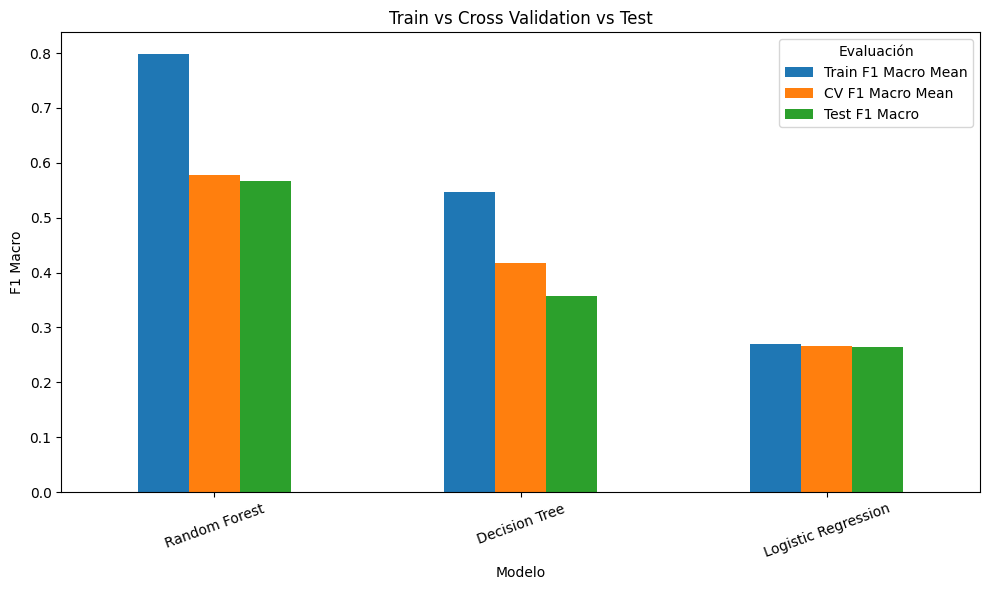

In [17]:
# ==========================================
# Visualización de Overfitting
# ==========================================

plot_df = overfitting_df.set_index("Model")[
    [
        "Train F1 Macro Mean",
        "CV F1 Macro Mean",
        "Test F1 Macro"
    ]
]

plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("F1 Macro")
plt.xlabel("Modelo")
plt.title("Train vs Cross Validation vs Test")

plt.xticks(rotation=20)
plt.legend(title="Evaluación")

plt.tight_layout()
plt.show()


## 15. Matriz de confusión

La matriz de confusión muestra cómo se distribuyen las predicciones respecto a las clases reales.

- La diagonal representa las predicciones correctas.
- Los valores fuera de la diagonal representan errores.

En mantenimiento predictivo, este análisis permite identificar qué tipos de falla están siendo confundidos por el modelo seleccionado.


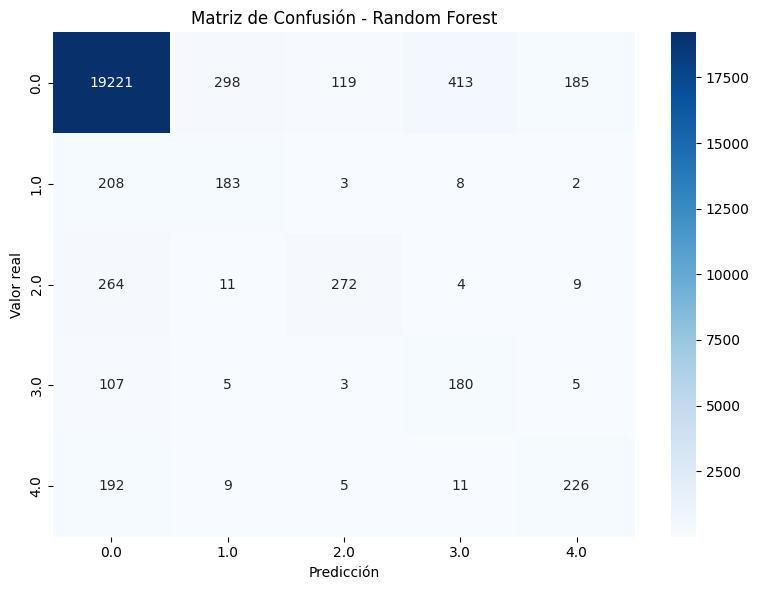

In [18]:
# ==========================================
# 15. Matriz de confusión
# ==========================================

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred_best
)

classes = np.sort(
    y.unique()
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title(
    f"Matriz de Confusión - {best_model_name}"
)

plt.tight_layout()
plt.show()


## 16. Classification Report

Analizamos Precision, Recall y F1 para cada clase individual.

Esto permite detectar situaciones donde el desempeño global parece bueno, pero una clase específica presenta un desempeño deficiente.

El análisis por clase es especialmente importante cuando existe desbalance.


In [19]:
# ==========================================
# 16. Classification Report
# ==========================================

print(
    classification_report(
        y_test,
        y_pred_best,
        zero_division=0
    )
)


              precision    recall  f1-score   support

         0.0       0.96      0.95      0.96     20236
         1.0       0.36      0.45      0.40       404
         2.0       0.68      0.49      0.57       560
         3.0       0.29      0.60      0.39       300
         4.0       0.53      0.51      0.52       443

    accuracy                           0.92     21943
   macro avg       0.56      0.60      0.57     21943
weighted avg       0.93      0.92      0.92     21943



## 17. Feature Importance

Analizamos qué variables tienen mayor influencia en el modelo seleccionado.

Los modelos basados en árboles proporcionan `feature_importances_`.

En Logistic Regression utilizamos el valor absoluto de sus coeficientes.

Como todos los modelos están almacenados en un Pipeline, accedemos al clasificador mediante `named_steps`.


,Variable,Importance
28,error5sum_rollingmean_24,0.077516
24,error1sum_rollingmean_24,0.069992
4,pressure_rollingmean_12,0.060302
12,pressure_rollingmean_24,0.050456
6,vibration_rollingmean_12,0.048330
2,rotate_rollingmean_12,0.048310
16,volt_rollingmean_36,0.042831
33,age,0.041582
14,vibration_rollingmean_24,0.041175
0,volt_rollingmean_12,0.040484


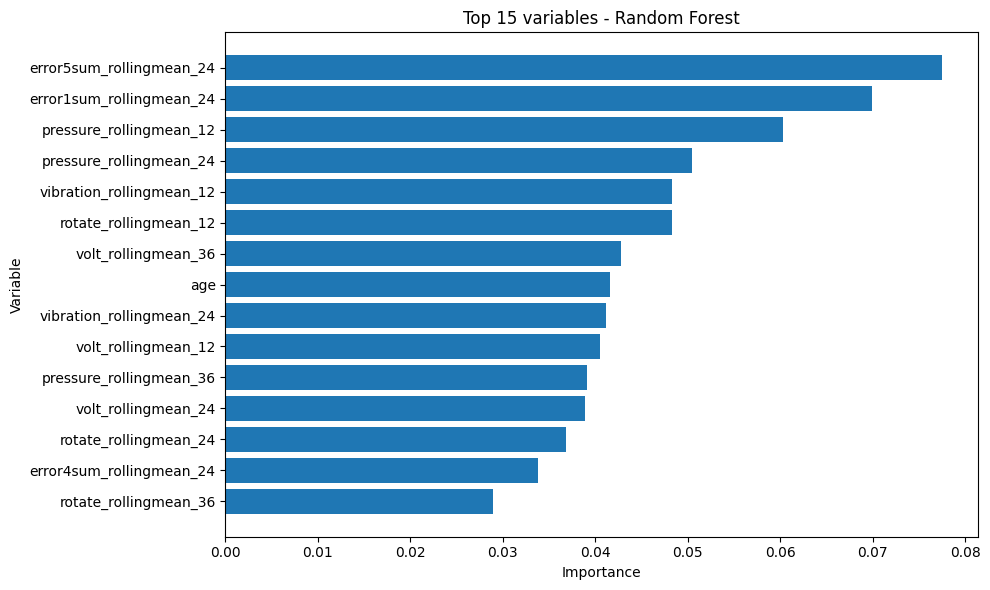

In [20]:
# ==========================================
# 17. Feature Importance
# ==========================================

classifier = best_model.named_steps["classifier"]

if hasattr(classifier, "feature_importances_"):

    importance_values = classifier.feature_importances_

elif hasattr(classifier, "coef_"):

    importance_values = np.mean(
        np.abs(classifier.coef_),
        axis=0
    )

else:

    importance_values = None


if importance_values is not None:

    feature_importance = pd.DataFrame({
        "Variable": input_features,
        "Importance": importance_values
    })

    feature_importance = (
        feature_importance
        .sort_values(
            "Importance",
            ascending=False
        )
    )

    display(
        feature_importance.head(20)
    )

    plt.figure(figsize=(10, 6))

    top_features = (
        feature_importance
        .head(15)
        .sort_values("Importance")
    )

    plt.barh(
        top_features["Variable"],
        top_features["Importance"]
    )

    plt.xlabel("Importance")
    plt.ylabel("Variable")
    plt.title(
        f"Top 15 variables - {best_model_name}"
    )

    plt.tight_layout()
    plt.show()

else:

    print(
        "El modelo seleccionado no expone "
        "una medida directa de importancia."
    )


## 18. Guardar modelo y métricas

Persistimos el mejor modelo como `best_model.pkl`.

El modelo almacenado incluye el **Pipeline completo**, incluyendo:

- escalamiento cuando corresponde;
- SMOTE cuando fue necesario;
- clasificador.

Esto es importante porque el endpoint debe reproducir exactamente el mismo proceso aplicado durante el entrenamiento.

También guardamos:

- comparación de modelos;
- análisis de overfitting.

Estos artefactos documentan la selección del modelo y serán utilizados en las siguientes etapas.


In [21]:
# ==========================================
# 18. Guardar modelo
# ==========================================

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_model.pkl"
)

RESULTS_PATH = os.path.join(
    MODEL_DIR,
    "model_comparison.csv"
)

OVERFITTING_PATH = os.path.join(
    MODEL_DIR,
    "overfitting_analysis.csv"
)

joblib.dump(
    best_model,
    BEST_MODEL_PATH
)

results_df.to_csv(
    RESULTS_PATH,
    index=False
)

overfitting_df.to_csv(
    OVERFITTING_PATH,
    index=False
)

print("Modelo guardado:")
print(BEST_MODEL_PATH)

print("\nComparación guardada:")
print(RESULTS_PATH)

print("\nAnálisis de overfitting guardado:")
print(OVERFITTING_PATH)

print(
    f"\nModelo seleccionado: {best_model_name}"
)


Modelo guardado:
../models/best_model.pkl

Comparación guardada:
../models/model_comparison.csv

Análisis de overfitting guardado:
../models/overfitting_analysis.csv

Modelo seleccionado: Random Forest


# Resumen de resultados

Al finalizar este notebook debemos tener:

```text
✓ Distribución de clases analizada
✓ Imbalance diagnosticado
✓ SMOTE aplicado correctamente si era necesario
✓ Logistic Regression como baseline
✓ 4 modelos entrenados
✓ Cross Validation
✓ 6 métricas de evaluación
✓ Análisis de overfitting
✓ Matriz de confusión
✓ Classification Report
✓ Feature Importance
✓ Mejor modelo seleccionado
✓ best_model.pkl generado
```

El siguiente paso será utilizar el modelo seleccionado en **Notebook 4 — Hyperparameter Tuning**, donde optimizaremos sus hiperparámetros y volveremos a validar su desempeño.
